In [45]:
#imports
import pandas as pd
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

In [8]:
#read in data
netflix_data = pd.read_csv('/Users/donyabehroozi/Documents/gsb545/GSB-545/Project Files/netflix_user_behavior_dataset.csv')
netflix_data.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


## EDA

In [10]:
# check number of rows and columns
netflix_data.shape

(50000, 20)

In [11]:
# check data types
netflix_data.dtypes

user_id                       object
age                            int64
gender                        object
country                       object
account_age_months             int64
subscription_type             object
monthly_fee                  float64
payment_method                object
primary_device                object
devices_used                   int64
favorite_genre                object
avg_watch_time_minutes         int64
watch_sessions_per_week        int64
binge_watch_sessions           int64
completion_rate                int64
rating_given                 float64
content_interactions           int64
recommendation_click_rate      int64
days_since_last_login          int64
churned                       object
dtype: object

In [12]:
#check for missing values
netflix_data.isna().sum()

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

In [13]:
#check for duplicates
netflix_data.duplicated().sum()

np.int64(0)

In [ ]:
#quantitative variables summary statistics
netflix_data.describe()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


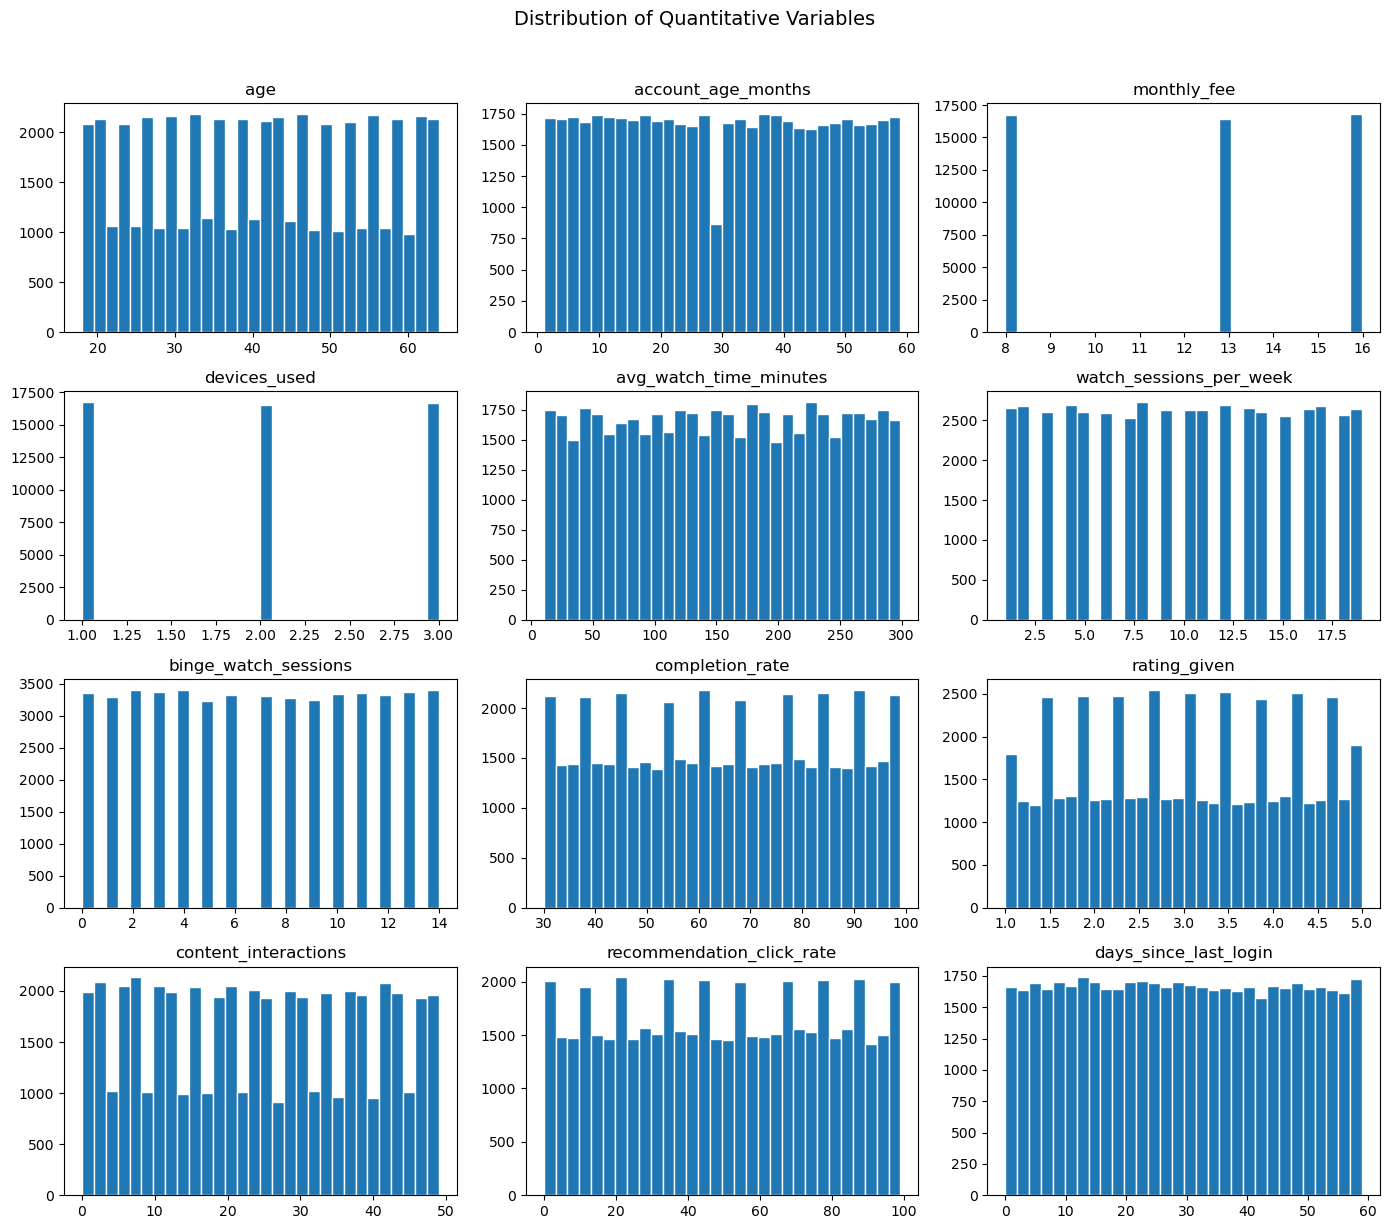

In [ ]:
#visualization of quantitative variables
quant_vars = [
    'age', 'account_age_months', 'monthly_fee', 'devices_used',
    'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions',
    'completion_rate', 'rating_given', 'content_interactions',
    'recommendation_click_rate', 'days_since_last_login'
]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(quant_vars):
    axes[i].hist(netflix_data[var], bins=30, edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Quantitative Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('histogram_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
#categorical variable summary
netflix_data.describe(include = ['object'])

,user_id,gender,country,subscription_type,payment_method,primary_device,favorite_genre,churned
count,50000,50000,50000,50000,50000,50000,50000,50000
unique,50000,3,10,3,4,4,8,2
top,U100000,Female,Brazil,Standard,PayPal,Mobile,Documentary,No
freq,1,16759,5116,19931,12539,12585,6352,40036


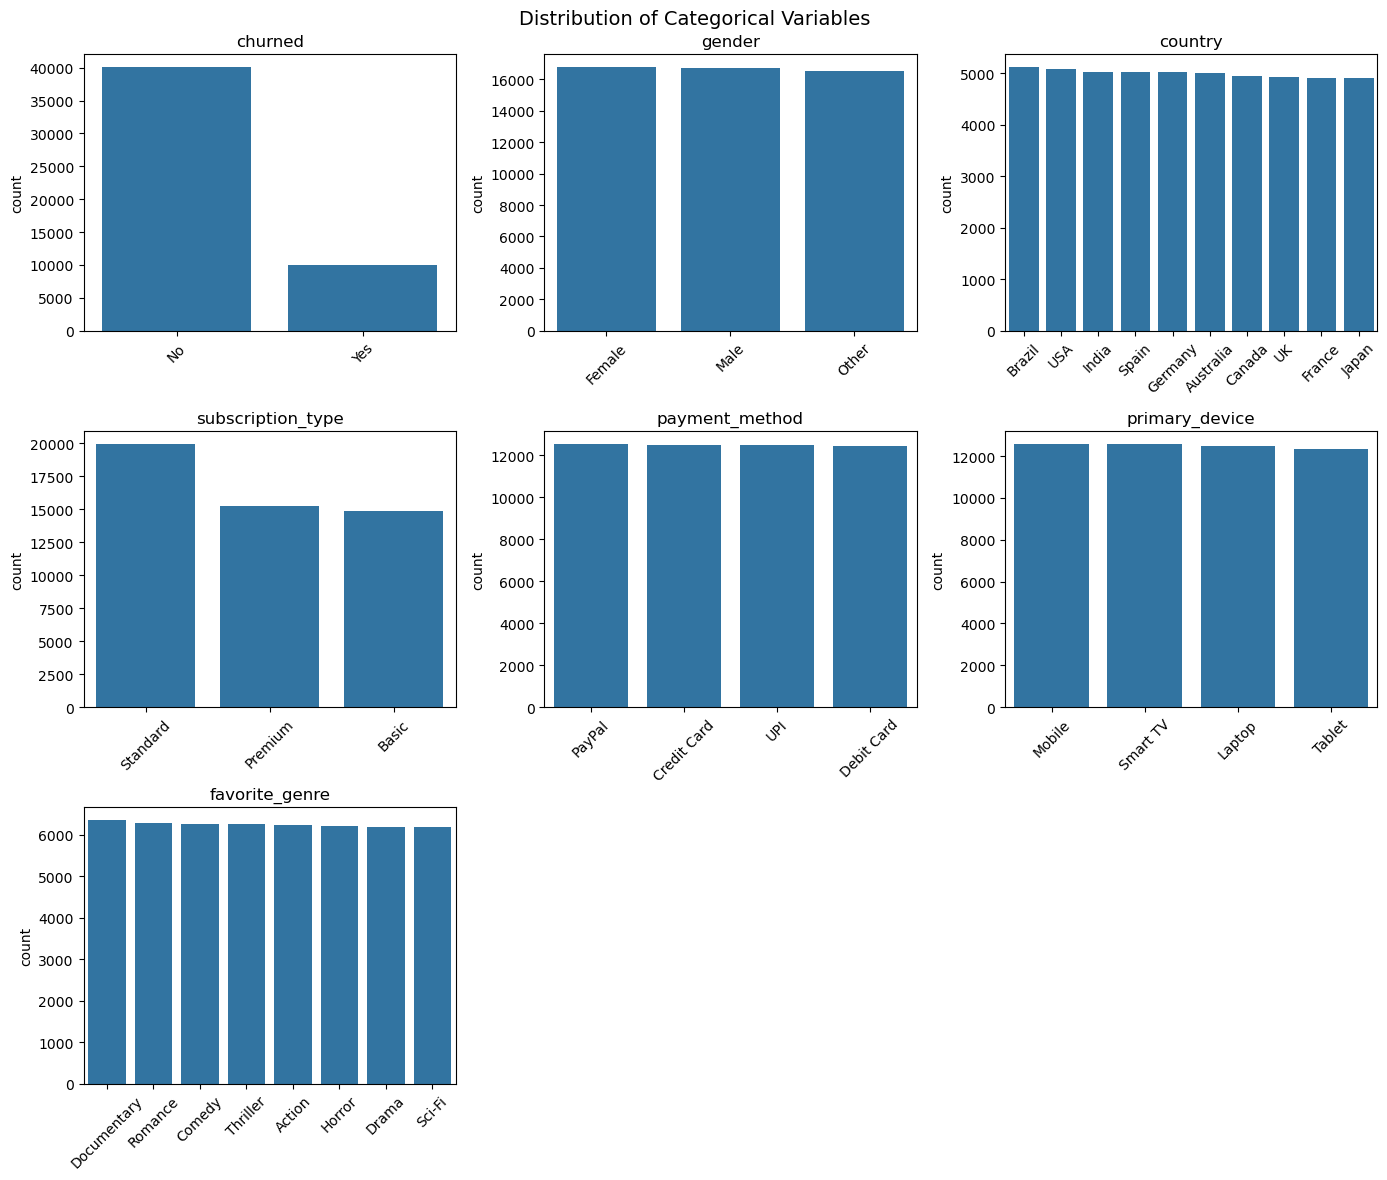

In [40]:
cat_vars = [
    'churned', 'gender', 'country', 'subscription_type',
    'payment_method', 'primary_device', 'favorite_genre'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = netflix_data[var].value_counts().index  # sort bars by frequency
    sns.countplot(data=netflix_data, x=var, ax=axes[i], order=order)
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# hide the 2 unused subplots (7 variables, 9 slots)
for j in range(len(cat_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Categorical Variables', fontsize=14)
plt.tight_layout()
plt.savefig('categorical_panel.png', dpi=150, bbox_inches='tight')
plt.show()